In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime

In [2]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [3]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

### Calculate distance between client and merch where there card was been used

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km


In [5]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
    df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
    te = TargetEncoder()
    le_job = le.fit_transform(df['job'])
    df['le_job'] = le_job
    le_street = le.fit_transform(df['street'])
    df['le_street'] = le_street
    le_merchant = le.fit_transform(df['merchant'])
    df['le_merchant'] = le_merchant
    le_city = le.fit_transform(df['city'])
    df['le_city'] = le_city
    le_state = le.fit_transform(df['state'])
    le_category = le.fit_transform(df['category'])
    df['le_category'] = le_category
    
    return df
    
    
    

In [6]:
df = data_processing('../fraudTrain.csv')

In [7]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch,le_gender,le_job,le_street,le_merchant,le_city,le_category
1294226,2020-06-20 15:12:35,3511378610369890,fraud_Fisher Inc,shopping_net,9.8,James,Cooper,M,663 Ramirez Trace Apt. 951,Huntsville,AL,35811,34.7789,-86.5438,190178,Television production assistant,1973-04-01,6d3348c122226541de1a8343d8a56c8d,1371741155,34.242113,-85.944039,0,2020,6,20,1900-01-01 15:12:35,51,81.133075,1,459,664,174,368,11


In [8]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'le_street', 'job', 'first', 'last', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df.drop(columns=columns_to_drop)

In [9]:
df_1.sample()

,amt,zip,lat,long,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,le_job,le_merchant,le_city,le_category
351384,55.23,50314,41.603,-93.633,222785,1339648274,0,2019,6,14,42,87.877534,1,252,479,210,3


In [10]:
df_1.corr()

,amt,zip,lat,long,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,le_job,le_merchant,le_city,le_category
amt,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,0.219404,0.000842,-0.001748,0.000629,-0.009801,-0.001085,0.001034,-0.000628,-0.002633,-0.000565,0.030867
zip,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.002162,0.000086,0.000852,-0.000607,0.010704,0.006183,-0.065951,-0.005678,0.001113,0.074757,0.002371
lat,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.001894,0.001274,-0.001072,-0.000138,0.048434,-0.072634,0.042935,-0.027593,-0.002266,-0.032044,-0.008660
long,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,0.001721,0.000191,-0.001213,0.000031,-0.029756,0.004058,0.050404,-0.002729,-0.000697,-0.066703,-0.000767
city_pop,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,0.002136,-0.001673,0.000137,0.000159,-0.094112,0.010901,-0.028649,-0.054945,0.001911,0.034923,0.009386
unix_time,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,-0.005078,0.782582,0.184868,0.017162,-0.003637,-0.000633,-0.000960,0.000032,-0.000999,-0.000466,0.000182
is_fraud,0.219404,-0.002162,0.001894,0.001721,0.002136,-0.005078,1.000000,0.003004,-0.012409,0.003848,0.012405,0.000403,0.007642,-0.000093,-0.000536,-0.002092,0.020205
year,0.000842,0.000086,0.001274,0.000191,-0.001673,0.782582,0.003004,1.000000,-0.464879,-0.045759,-0.004396,-0.000595,-0.000654,-0.000545,-0.001130,-0.000216,-0.000556
month,-0.001748,0.000852,-0.001072,-0.001213,0.000137,0.184868,-0.012409,-0.464879,1.000000,0.012434,0.002210,0.000098,-0.000215,0.000960,0.000453,-0.000338,0.000768
day,0.000629,-0.000607,-0.000138,0.000031,0.000159,0.017162,0.003848,-0.045759,0.012434,1.000000,0.000571,-0.000594,-0.000206,-0.000811,-0.001014,-0.000081,-0.000720


In [11]:
df_test = data_processing('../fraudTest.csv')

In [12]:
df_2 = df_test.drop(columns=columns_to_drop)

In [13]:
df_2.sample()

,amt,zip,lat,long,city_pop,unix_time,is_fraud,year,month,day,age,dist_client_merch,le_gender,le_job,le_merchant,le_city,le_category
258708,104.17,82514,43.0048,-108.8964,1645,1380011980,0,2020,9,24,48,84.396893,1,194,367,258,11


# Model Development

In [14]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [15]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

## Data Split

In [16]:
from sklearn.model_selection import train_test_split


In [17]:
X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.3, random_state=40)


In [18]:
print("X_train_unbalanced shape:", X_train_unbalanced.shape)
print("X_test_unbalanced shape:", X_test_unbalanced.shape)
print("y_train_unbalanced shape:", y_train_unbalanced.shape)
print("y_test_unbalanced shape:", y_test_unbalanced.shape)

X_train_unbalanced shape: (907672, 16)
X_test_unbalanced shape: (389003, 16)
y_train_unbalanced shape: (907672,)
y_test_unbalanced shape: (389003,)


In [19]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


## Model without balancing

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [21]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

In [33]:
lr.fit(X,y)
y_pred_lr = lr.predict(X_test_actual)
y_prob_lr = lr.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9955139198047934
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719

ROC AUC Score: 0.8274654473941291


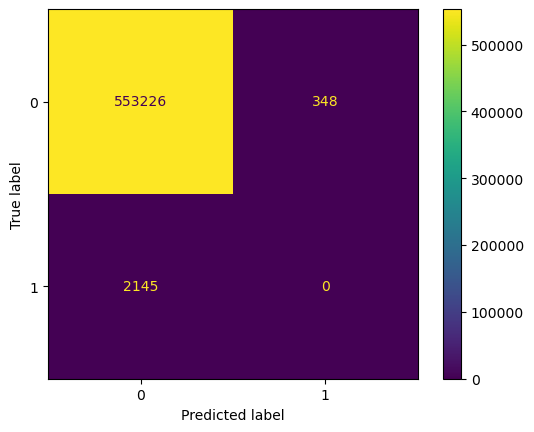

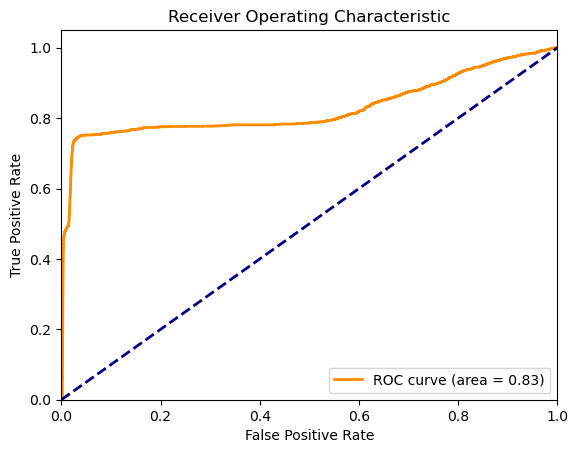

In [34]:
measure_metrics(y_test_actual, y_pred_lr, y_prob_lr)

In [23]:
dt.fit(X, y)

DecisionTreeClassifier()

In [29]:
y_pred_dt = dt.predict(X_test_actual)
y_prob_dt = dt.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9942003062698954
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.35      0.60      0.44      2145

    accuracy                           0.99    555719
   macro avg       0.68      0.80      0.72    555719
weighted avg       1.00      0.99      0.99    555719

ROC AUC Score: 0.7976316838788704


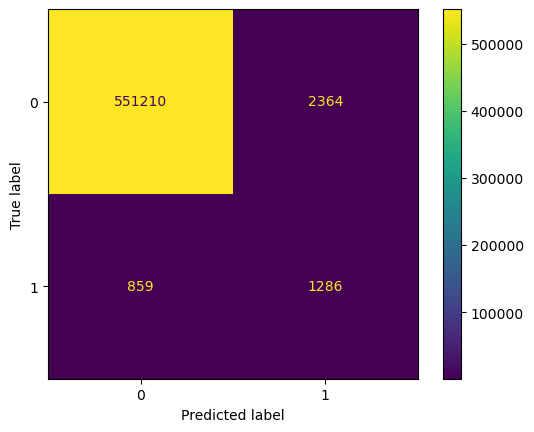

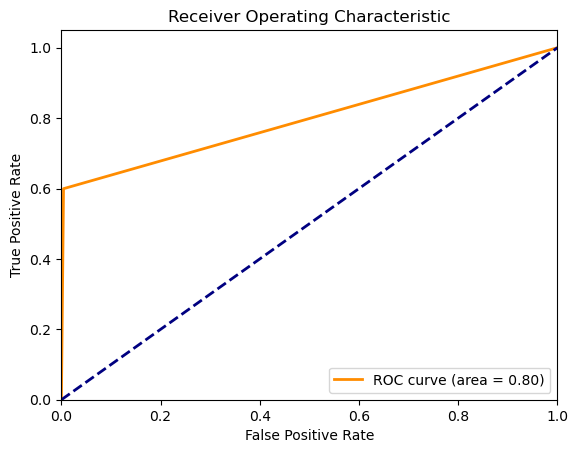

In [32]:
measure_metrics(y_test_actual, y_pred_dt, y_prob_dt)

## Model with balancing

In [23]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train_unbalanced, y_train_unbalanced)

In [48]:
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(X_train_smote, y_train_smote, test_size=0.3, random_state=40)


In [49]:
print("X_train_unbalanced shape:", X_train_balanced.shape)
print("X_test_unbalanced shape:", X_test_balanced.shape)
print("y_train_unbalanced shape:", y_train_balanced.shape)
print("y_test_unbalanced shape:", y_test_balanced.shape)

X_train_unbalanced shape: (1804836, 16)
X_test_unbalanced shape: (773502, 16)
y_train_unbalanced shape: (1804836,)
y_test_unbalanced shape: (773502,)


In [37]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [39]:
y_pred_rf_smote = rf_smote.predict(X_test_actual)
y_prob_rf_smote = rf_smote.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9961563308074765
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.50      0.24      0.32      2145

    accuracy                           1.00    555719
   macro avg       0.75      0.62      0.66    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9298418706134747


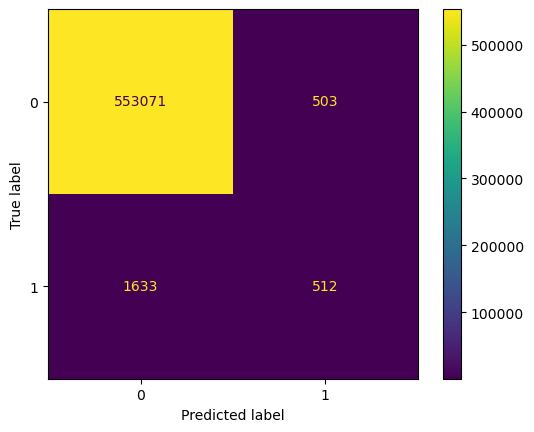

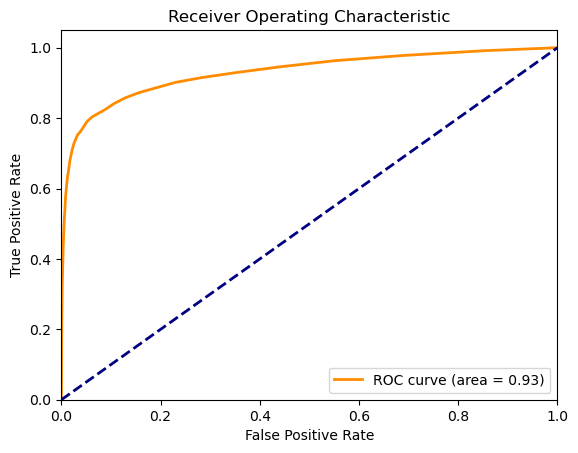

In [40]:
measure_metrics(y_test_actual, y_pred_rf_smote, y_prob_rf_smote)

In [51]:
rf_smote_train = RandomForestClassifier()
rf_smote_train.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier()

In [52]:
y_pred_rf_smote_train = rf_smote_train.predict(X_test_balanced)
y_prob_rf_smote_train = rf_smote_train.predict_proba(X_test_balanced)[:, 1]

Accuracy: 0.9969204992359425
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    386291
           1       0.99      1.00      1.00    387211

    accuracy                           1.00    773502
   macro avg       1.00      1.00      1.00    773502
weighted avg       1.00      1.00      1.00    773502

ROC AUC Score: 0.999958181531143


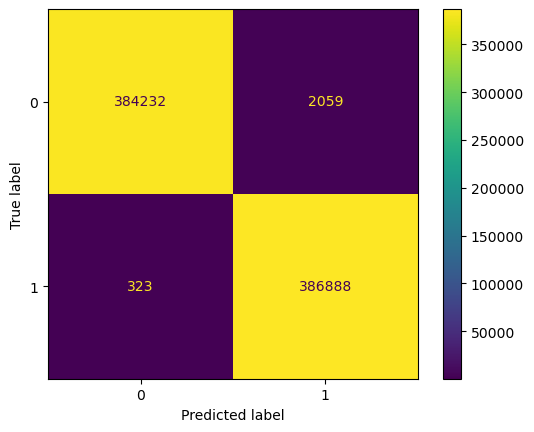

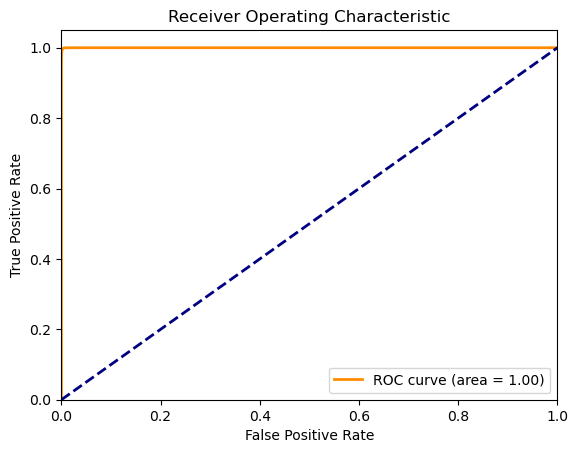

In [54]:
measure_metrics(y_test_balanced, y_pred_rf_smote_train, y_prob_rf_smote_train)

In [24]:
rf_smote_tuned = RandomForestClassifier(
    n_estimators=1000,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=70,
    bootstrap=False,
    random_state=101
)

In [25]:
rf_smote_tuned.fit(X_train_smote, y_train_smote)

RandomForestClassifier(bootstrap=False, max_depth=70, n_estimators=1000,
                       random_state=101)

In [27]:
y_pred_rf_smote_tuned = rf_smote_tuned.predict(X_test_unbalanced)
y_prob_rf_smote_tuned = rf_smote_tuned.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9951594203643673
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386749
           1       0.56      0.75      0.64      2254

    accuracy                           1.00    389003
   macro avg       0.78      0.87      0.82    389003
weighted avg       1.00      1.00      1.00    389003

ROC AUC Score: 0.9893636376966144


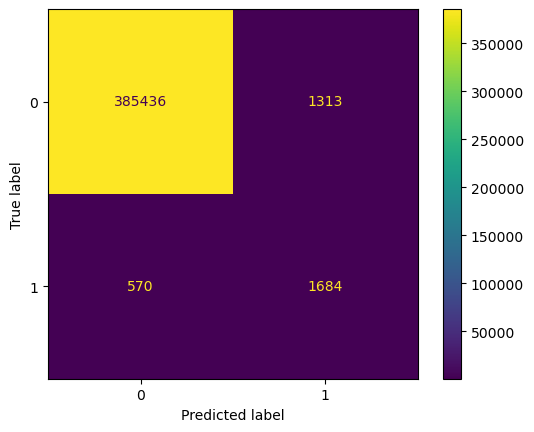

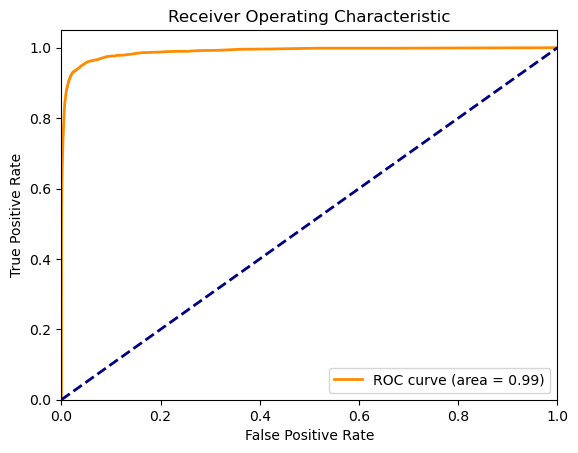

In [28]:
measure_metrics(y_test_unbalanced, y_pred_rf_smote_tuned, y_prob_rf_smote_tuned)

In [29]:
y_pred_rf_smote_test_tuned = rf_smote_tuned.predict(X_test_actual)
y_prob_rf_smote_test_tuned = rf_smote_tuned.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9961995181017744
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.52      0.19      0.27      2145

    accuracy                           1.00    555719
   macro avg       0.76      0.59      0.64    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9340985384712149


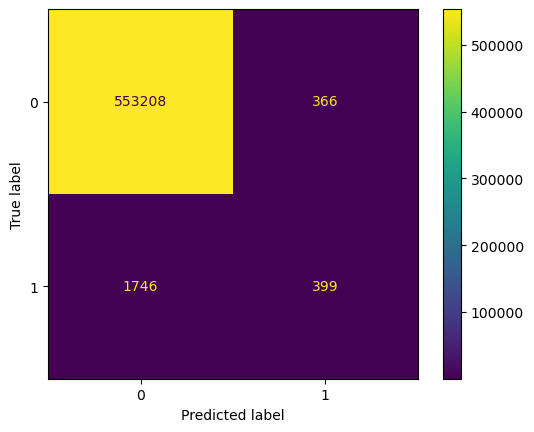

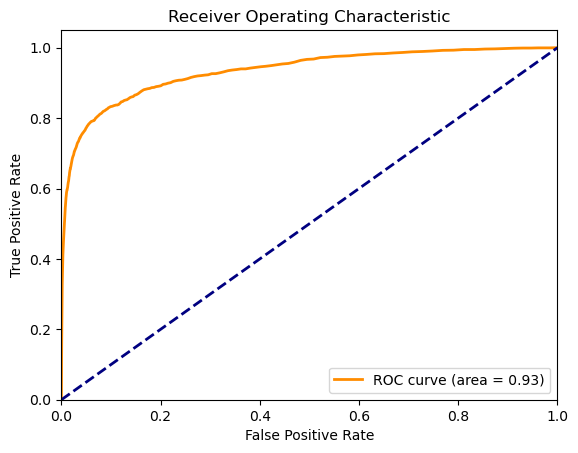

In [35]:
measure_metrics(y_test_actual, y_pred_rf_smote_test_tuned, y_prob_rf_smote_test_tuned)

### XGBoost

In [32]:
import xgboost as xgb

In [33]:
xgb_model = xgb.XGBClassifier()

In [36]:
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [38]:
y_pred_xgb_smote_test = xgb_model.predict(X_test_actual)
y_prob_xgb_smote_test = xgb_model.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9700568092867079
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.08      0.64      0.14      2145

    accuracy                           0.97    555719
   macro avg       0.54      0.80      0.56    555719
weighted avg       0.99      0.97      0.98    555719

ROC AUC Score: 0.9111043635473973


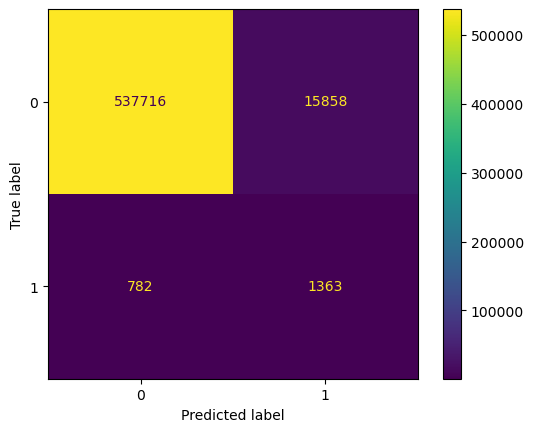

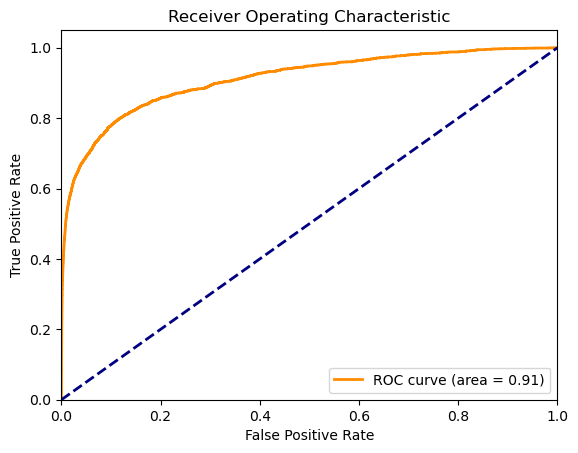

In [39]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test, y_prob_xgb_smote_test)

In [43]:
y_pred_xgb_smote_train = xgb_model.predict(X_test_unbalanced)
y_prob_xgb_smote_train = xgb_model.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9853702927740917
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    386749
           1       0.27      0.89      0.41      2254

    accuracy                           0.99    389003
   macro avg       0.63      0.94      0.70    389003
weighted avg       1.00      0.99      0.99    389003

ROC AUC Score: 0.9816294830511525


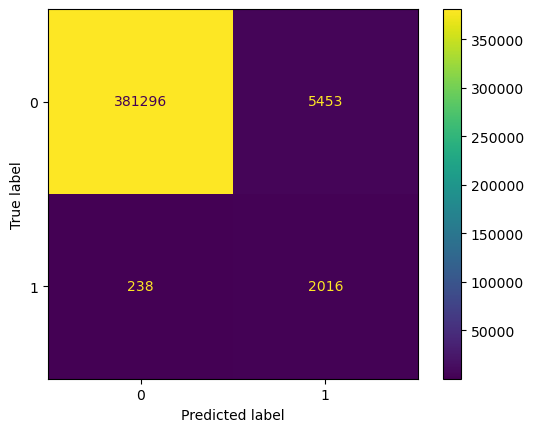

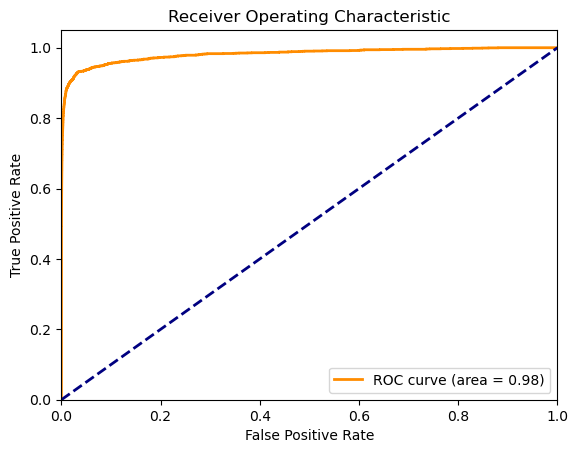

In [44]:
measure_metrics(y_test_unbalanced, y_pred_xgb_smote_train, y_prob_xgb_smote_train)

In [50]:
xgb_model_tune = xgb.XGBClassifier(eval_metric='logloss')


In [51]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0]
}


In [52]:
from sklearn.model_selection import RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='precision', cv=3, verbose=2, 
                                   random_state=42)



In [53]:
xgb_random_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.0s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   9.7s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   9.7s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   5.7s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   5.9s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total ti

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=0, reg_lambda=0.1, subsample=0.8; total time=  10.2s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=0, reg_lambda=0.1, subsample=0.8; total time=   9.5s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=400, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=  11.9s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=400, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=  11.7s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=400, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=  11.2s
[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=10, n_estimators=300, reg_alpha=0, reg_lambda=0.1, subsample=0.6; total time=  10.5s
[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0

[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=9, n_estimators=500, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=  14.6s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=9, n_estimators=500, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=  14.9s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=9, n_estimators=500, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=  13.8s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.8; total time=  12.8s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.8; total time=  11.8s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=8, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.8; total time=  12.6s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.01, ma

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   8.9s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  17.6s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  17.8s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  17.4s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=  10.1s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.9s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.

[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.9; total time=   4.6s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.9; total time=   4.6s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   2.2s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   2.2s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   2.3s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=9, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.9; total time=  15.6s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_dept

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=3, n_estimators=400, reg_alpha=0.1, reg_lambda=0, subsample=0.7; total time=   8.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=3, n_estimators=400, reg_alpha=0.1, reg_lambda=0, subsample=0.7; total time=   8.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=3, n_estimators=400, reg_alpha=0.1, reg_lambda=0, subsample=0.7; total time=   8.0s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.15, max_depth=3, n_estimators=300, reg_alpha=0.1, reg_lambda=0, subsample=0.7; total time=   6.1s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.15, max_depth=3, n_estimators=300, reg_alpha=0.1, reg_lambda=0, subsample=0.7; total time=   6.2s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.15, max_depth=3, n_estimators=300, reg_alpha=0.1, reg_lambda=0, subsample=0.7; total time=   6.4s
[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.2, max_depth=7,

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='precision', verbose=2)

In [54]:
xgb_random_search.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [59]:
xgb_random_search.best_params_

{'subsample': 0.7,
 'reg_lambda': 0.5,
 'reg_alpha': 0.1,
 'n_estimators': 500,
 'max_depth': 9,
 'learning_rate': 0.15,
 'gamma': 0.1,
 'colsample_bytree': 0.6}

In [55]:
y_pred_xgb_smote_train_tuned = xgb_random_search.predict(X_test_unbalanced)
y_prob_xgb_smote_train_tuned = xgb_random_search.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9984704488140195
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386749
           1       0.85      0.89      0.87      2254

    accuracy                           1.00    389003
   macro avg       0.93      0.94      0.93    389003
weighted avg       1.00      1.00      1.00    389003

ROC AUC Score: 0.9957343702529503


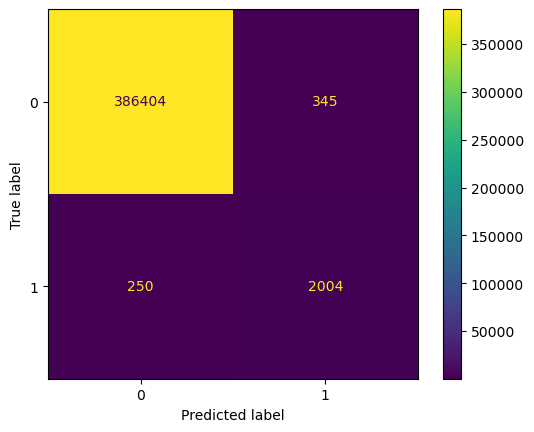

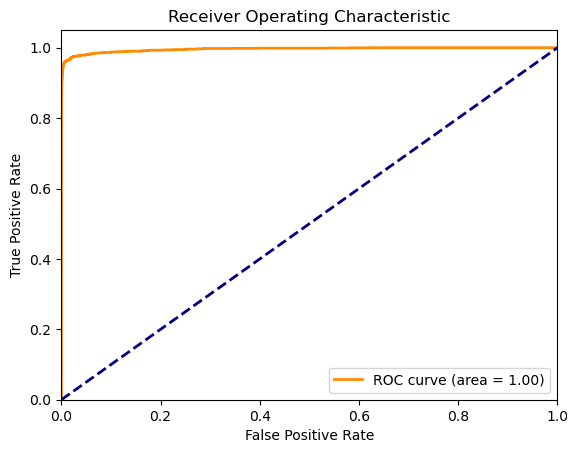

In [56]:
measure_metrics(y_test_unbalanced, y_pred_xgb_smote_train_tuned, y_prob_xgb_smote_train_tuned)

In [57]:
y_pred_xgb_smote_test_tuned = xgb_random_search.predict(X_test_actual)
y_prob_xgb_smote_test_tuned = xgb_random_search.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9959170012182416
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.46      0.36      0.40      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.68      0.70    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9199647469026089


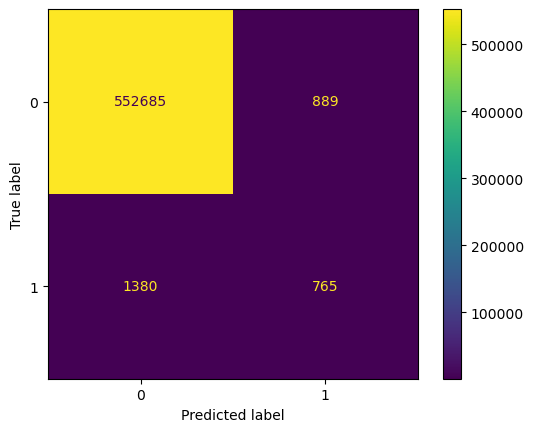

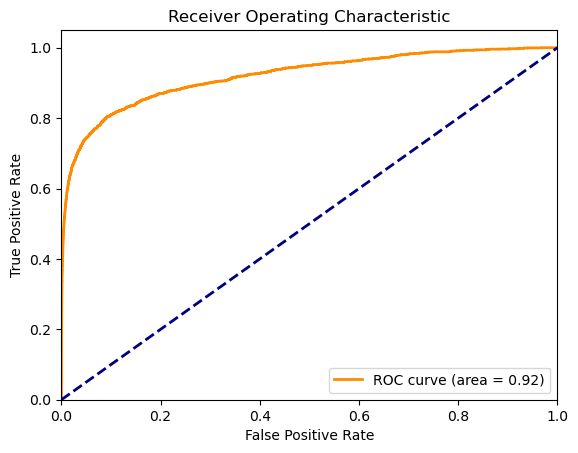

In [58]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test_tuned, y_prob_xgb_smote_test_tuned)